In [2]:
import os 
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
import torch 
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)
from omegaconf import OmegaConf
import torch 
import numpy as np
import random
from compo_predictive_learning.models import create_model
import hydra
import logging
from collections import defaultdict
from compo_predictive_learning.datasets import make_sketch_dataloaders
logger = logging.getLogger(__name__)


In [3]:

def set_seed(seed=0):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

np.set_printoptions(precision=5, suppress=True, linewidth=200)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [4]:
from hydra import initialize, initialize_config_module, initialize_config_dir, compose

with initialize_config_dir(version_base=None, config_dir="/home/ghb24/paper_git/er/comp_predictive_learning/scripts/configs"):
    config = compose(config_name="train_rnn.yaml")


/home/ghb24/miniconda3/envs/pre/lib/python3.10/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'train_rnn.yaml': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


In [5]:
config.rnn.activation = "tanh"

In [6]:
set_seed(config.seed)   
pretrain_loader,val_loader, smaller_pretrain_loader,analysis_loader,classification_metric_train_loaders, classification_metric_val_loaders,latent_names, train_contexts,val_contexts = make_sketch_dataloaders(config)

all_contexts = train_contexts + val_contexts

model = create_model(config).to(DEVICE)


--- Generating Support: 'full' ---
Total contexts: 54
Train contexts: 43
Validation contexts: 11


/home/ghb24/miniconda3/envs/pre/lib/python3.10/site-packages/torch/utils/data/sampler.py:76: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


Output shape from conv layers 1024


In [7]:
# model.load_state_dict(torch.load("/home/ghb24/comp_predictive_learning/test/contextual_full_1_0.8/sketch_6/['white', 'red', 'green', 'blue']/[1]/False/[1]_512_128_128_64_16/['next_primitive_offset', 'next_color_offset', 'next_position_offset', 'next_scale_offset']/[0, 1, 2, 3, 4, 5]/[0]/[0, 1, 2]/[0, 1, 2]/ae_pred/conv_[16, 16, 16]_relu_none_False_512/rnn_256_relu_1_False_eye_0.05/conv_[16, 16, 16]_relu_none/True/5000_0.001_0.001_0.01_0_0_128/seed0/model_step_4999.pth"))

model.load_state_dict(torch.load("/home/ghb24/paper_git/er/comp_predictive_learning/revieww/contextual_full_1_0.8/sketch_6/['white', 'red', 'green', 'blue']/[1]/False/[1]_512_128_128_64_16/['next_primitive_offset', 'next_color_offset', 'next_position_offset', 'next_scale_offset']/[0, 1, 2, 3, 4, 5]/[0]/[0, 1, 2]/[0, 1, 2]/ae_pred/conv_[16, 16, 16]_relu_none_False_512/rnn_512_tanh_1_False_eye_0.05/conv_[16, 16, 16]_relu_none/True/5000_0.001_0.0001_0.001_0_0_128/seed0/model_step_4999.pth"))
# model.load_state_dict(torch.load("/home/ghb24/comp_predictive_learning/test/contextual_full_1_0.8/sketch_6_4/['white', 'red', 'green', 'blue']/[1]/False/[1]_512_128_128_64_16/['next_primitive_offset', 'next_color_offset', 'next_position_offset', 'next_scale_offset']/[0, 1, 2]/[0]/[0, 1, 2]/[0, 1, 2]/ae_pred/conv_[16, 16, 16]_relu_none_False_512/rnn_512_relu_1_False_eye_0.05/conv_[16, 16, 16]_relu_none/True/5000_0.001_0.001_0.01_0_0_128/seed0/model_step_4999.pth"))

/tmp/ipykernel_4013842/209621624.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home/ghb24/paper_git/er/comp_predictive_learning/revi

<All keys matched successfully>

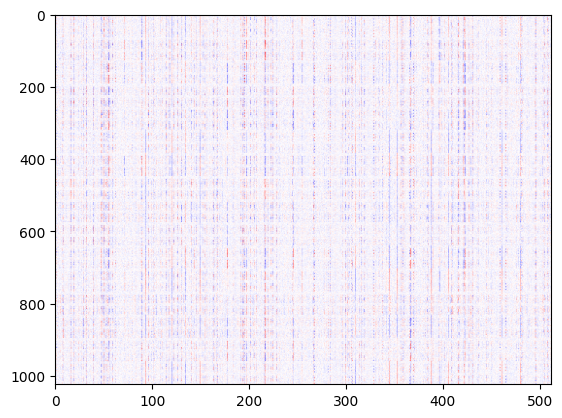

In [14]:
import matplotlib.pyplot as plt
plt.imshow(model.decoder.fc.weight.cpu().detach().numpy(), aspect="auto", cmap="bwr")

In [9]:
model.decoder.fc.weight

Parameter containing:
tensor([[ 1.7544e-02,  6.1172e-02,  9.4349e-03,  ...,  1.2290e-04,
         -1.4008e-02,  2.1423e-02],
        [-1.6657e-02, -1.0840e-01, -2.5178e-03,  ...,  8.4309e-03,
          4.6134e-02,  2.3979e-02],
        [ 2.1457e-02,  1.2448e-01, -2.4639e-02,  ..., -7.3899e-03,
          4.7638e-03, -1.4025e-03],
        ...,
        [ 1.6259e-02,  6.8292e-03, -1.6985e-03,  ...,  1.9924e-03,
         -8.0629e-02, -4.1600e-02],
        [ 2.1847e-02, -2.1666e-03, -5.5627e-03,  ..., -3.3499e-02,
         -2.0386e-02, -5.3544e-03],
        [ 8.9695e-03,  1.3948e-02, -1.5623e-02,  ...,  9.4235e-03,
          1.6431e-03,  4.7769e-03]], device='cuda:0', requires_grad=True)

In [7]:
import matplotlib.pyplot as plt

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.309571..0.97414213].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.18169539..0.6027529].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.24105828..1.1621782].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13669908..1.2627203].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.14285655..1.0337378].


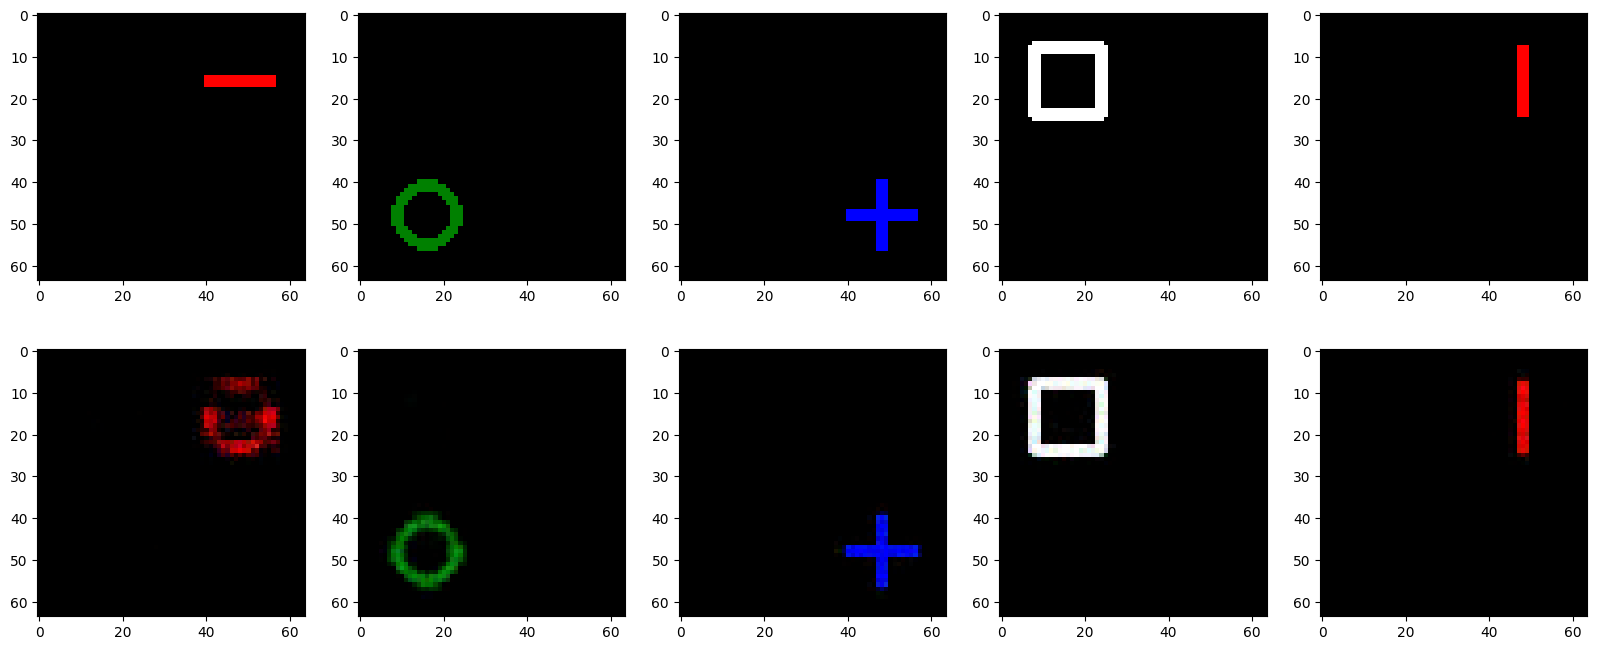

In [8]:
for batch in val_loader:
    imgs, latents, contexts = batch
    out,cnn_encoded,rnn_out,_ = model(imgs)

    fix,ax = plt.subplots(2,5, figsize=(20,8))
    for i in range(5):
        ax[0][i].imshow(imgs[i+1,0].cpu().numpy().transpose(1,2,0))
        ax[1][i].imshow(out[i,0].detach().cpu().numpy().transpose(1,2,0))
    break

In [9]:
import torch 
from sklearn.svm import LinearSVC
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def unpack_batch(batch):
    if len(batch) == 3:
        prim_sequence_inputs, latents, contexts = batch
    else:   
        prim_sequence_inputs, latents = batch
    prim_sequence_inputs = prim_sequence_inputs.transpose(0,1).to(DEVICE)
    latents = latents.transpose(0,1).to(DEVICE)
    return prim_sequence_inputs, latents

def disentanglement_metric(
            config,
             model,
             train_loader,
             val_loader,
             idx_to_classify):
    
    model.train()
    def get_activity_and_labels_b(loader):
        acti = []
        labels = []
        with torch.no_grad():
            for batch in loader:
                prim_sequence_inputs, latents = unpack_batch(batch)
                _,_,activity,_ = model(prim_sequence_inputs)
                acti.append(activity[-1:].cpu().flatten(0,1))
                labels.append(latents[-1:].cpu().flatten(0,1))
        return torch.cat(acti, dim=0), torch.cat(labels, dim=0)

    train_activities, train_latents = get_activity_and_labels_b(train_loader)
    val_activities, val_latents = get_activity_and_labels_b(val_loader)
    classifier =  LinearSVC(max_iter=5000,penalty="l1",C=10,random_state=0)
    classifier.fit(train_activities.numpy(), train_latents[:,idx_to_classify].cpu().numpy())
    latent_neurons = torch.abs(torch.from_numpy(classifier.coef_)).sum(dim=0) > 0
    train_acc = classifier.score(train_activities.numpy(), train_latents[:,idx_to_classify].cpu().numpy())
    val_acc = classifier.score(val_activities.numpy(), val_latents[:,idx_to_classify].cpu().numpy())

    return train_acc, val_acc,latent_neurons


def neurons_for_dynamic(
            config,
             model,
             train_loader,
             val_loader,
             latent_idx,
             ):
    
    model.train()
    def get_activity_and_labels_b(loader):
        acti = []
        labels = []
        with torch.no_grad():
            for batch in loader:
                prim_sequence_inputs, latents = unpack_batch(batch)
                _,_,activity,_ = model(prim_sequence_inputs)
                acti.append(activity[-1:].cpu().flatten(0,1))
                labels.append(latents[-1:].cpu().flatten(0,1))
        return torch.cat(acti, dim=0), torch.cat(labels, dim=0)

    train_activities, train_latents = get_activity_and_labels_b(train_loader)
    val_activities, val_latents = get_activity_and_labels_b(val_loader)
    classifier =  LinearSVC(max_iter=5000,penalty="l1",C=10,random_state=0)
    classifier.fit(train_activities.numpy(), train_latents[:,latent_idx].cpu().numpy())
    latent_neurons = torch.abs(torch.from_numpy(classifier.coef_)).sum(dim=0) > 0
    train_acc = classifier.score(train_activities.numpy(), train_latents[:,latent_idx].cpu().numpy())
    val_acc = classifier.score(val_activities.numpy(), val_latents[:,latent_idx].cpu().numpy())

    return train_acc, val_acc,latent_neurons



In [10]:
latents = ["primitive", "color", "quadrant"]
latent_idx = 0

In [11]:
latents_to_neurons = defaultdict(torch.Tensor)
train_accs = {}
val_accs = {}
neurons_intersection  = torch.ones(512, dtype=torch.bool)
for lat in classification_metric_train_loaders.keys():
    classification_metric_train_loader,lat_idx = classification_metric_train_loaders[lat]
    classification_metric_val_loader = classification_metric_val_loaders[lat][0]
    train_acc,val_acc,latent_neurons = disentanglement_metric(config, model, idx_to_classify=lat_idx, train_loader=classification_metric_train_loader, val_loader=classification_metric_val_loader)
    latents_to_neurons[lat] = latent_neurons
    train_accs[lat] = train_acc
    val_accs[lat] = val_acc
    print(f"Latent: {lat}, Train acc: {train_acc}, Val acc: {val_acc}, Num neurons: {latent_neurons.sum().item()}")
    neurons_intersection = neurons_intersection & latent_neurons
print(f"Intersection of neurons across latents: {neurons_intersection.sum().item()}")

/home/ghb24/miniconda3/envs/pre/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Latent: primitive, Train acc: 1.0, Val acc: 1.0, Num neurons: 35
Latent: color, Train acc: 1.0, Val acc: 1.0, Num neurons: 20
Latent: position, Train acc: 1.0, Val acc: 1.0, Num neurons: 20
Intersection of neurons across latents: 1


In [12]:
import numpy as np
import torch

@torch.no_grad()
def collect_activity_latents(
    model,
    loader,
    *,
    activity_start_recording=0,
    feature="activity",          # "activity" or "delta_activity"
    color_time="post",           # for delta: "pre"|"post"
    time_subsample=1,
    subsample_batch=1,
    max_points=200000,
    seed=0,
    device=None,
):
    """
    Returns:
      A: [M, N]   activity or delta_activity samples
      Z: [M, L]   corresponding latent values at the same time index
    """
    rng = np.random.default_rng(seed)
    model.eval()

    A_list, Z_list = [], []

    for batch in loader:
        x, latents, ctx = batch  # ctx unused here but kept for compatibility
        latents = torch.cat((latents[:,:,:1], latents[:,:,2:]), dim=2)  # remove the second latent, scale
        if device is None:
            device = next(model.parameters()).device
        x = x.to(device)
        latents = latents.to(device)
        if subsample_batch < 1:
            idx = rng.choice(x.shape[1], size=int(x.shape[1]*subsample_batch), replace=False)
            x = x[:,idx]
            latents = latents[:,idx]
            
        lat_TBL = latents

        _, _, activity, _ = model(x)  # activity [T,B,N]
        A = activity

        # start recording
        if activity_start_recording > 0:
            A = A[activity_start_recording:]
            lat_TBL = lat_TBL[activity_start_recording:]

        if feature == "activity":
            Afeat = A                      # [T,B,N]
            Zfeat = lat_TBL                # [T,B,L]
        elif feature == "delta_activity":
            Afeat = A[1:] - A[:-1]         # [T-1,B,N]
            if color_time == "post":
                Zfeat = lat_TBL[1:]        # [T-1,B,L]
            elif color_time == "pre":
                Zfeat = lat_TBL[:-1]
            else:
                raise ValueError("color_time must be 'pre' or 'post'")
        else:
            raise ValueError("feature must be 'activity' or 'delta_activity'")

        # time subsample
        if time_subsample > 1:
            Afeat = Afeat[::time_subsample]
            Zfeat = Zfeat[::time_subsample]

        # flatten time and batch
        T, B, N = Afeat.shape
        L = Zfeat.shape[-1]

        A_np = Afeat.detach().cpu().reshape(T * B, N).numpy()
        Z_np = Zfeat.detach().cpu().reshape(T * B, L).numpy()

        A_list.append(A_np)
        Z_list.append(Z_np)

    A = np.concatenate(A_list, axis=0)
    Z = np.concatenate(Z_list, axis=0)

    # global cap
    if max_points is not None and A.shape[0] > max_points:
        idx = rng.choice(A.shape[0], size=max_points, replace=False)
        A = A[idx]
        Z = Z[idx]

    return A, Z

In [13]:
A, Z = collect_activity_latents(model, val_loader, feature="activity",subsample_batch=0.02, time_subsample=1, max_points=10000, seed=0)

In [15]:
import numpy as np

def _infer_latent_type(z_col, max_unique=30):
    u = np.unique(z_col)
    is_intlike = np.allclose(z_col, np.round(z_col))
    if is_intlike and u.size <= max_unique:
        return "categorical"
    return "continuous"

def _bin_continuous_quantiles(z, n_bins=20):
    # quantile binning; robust to scale, works for weird distributions
    qs = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(z, qs)

    # handle repeated edges (e.g. discrete-ish or constant)
    edges = np.unique(edges)
    if edges.size <= 2:
        # degenerate: everyone in one bin
        return np.zeros_like(z, dtype=np.int64), 1

    # bins in [0, K-1]
    bins = np.digitize(z, edges[1:-1], right=False)
    K = int(bins.max() + 1)
    return bins.astype(np.int64), K

def eta_squared_per_neuron(A, bins, K):
    """
    A: [M,N]
    bins: [M] in {0..K-1}
    returns eta2: [N]
    """
    M, N = A.shape
    mu = A.mean(axis=0)  # [N]
    ss_tot = ((A - mu) ** 2).sum(axis=0) + 1e-12

    ss_between = np.zeros((N,), dtype=np.float64)
    for k in range(K):
        idx = (bins == k)
        nk = int(idx.sum())
        if nk <= 1:
            continue
        muk = A[idx].mean(axis=0)
        ss_between += nk * (muk - mu) ** 2

    eta2 = ss_between / ss_tot
    return eta2

def neuron_latent_eta2(A, Z, latent_names=None, n_bins=20, max_unique=30):
    """
    Returns:
      eta2: [L,N] where eta2[i,n] is tuning strength of neuron n to latent i
      types: list of latent types
    """
    M, N = A.shape
    M2, L = Z.shape
    assert M == M2

    if latent_names is None:
        latent_names = [f"latent_{i}" for i in range(L)]

    eta2 = np.zeros((L, N), dtype=np.float64)
    types = []

    for i in range(L):
        z = Z[:, i]
        t = _infer_latent_type(z, max_unique=max_unique)
        types.append(t)

        if t == "categorical":
            cats = np.unique(z)
            # map to 0..K-1
            cat_to_k = {c: k for k, c in enumerate(np.sort(cats))}
            bins = np.array([cat_to_k[v] for v in z], dtype=np.int64)
            K = int(bins.max() + 1)
        else:
            bins, K = _bin_continuous_quantiles(z.astype(np.float64), n_bins=n_bins)

        eta2[i] = eta_squared_per_neuron(A.astype(np.float64), bins, K)

    return eta2, types, latent_names

def pick_selective_neurons(eta2, latent_names, min_eta2=0.03, selectivity_ratio=1.5, top_k=10):
    """
    For each latent, return top neurons with high eta2 and selective vs other latents.
    """
    L, N = eta2.shape
    per_latent = {}
    for i, name in enumerate(latent_names):
        s = eta2[i]
        order = np.argsort(-s)
        picks = []
        for n in order:
            best = float(s[n])
            if best < min_eta2:
                break
            other = np.delete(eta2[:, n], i)
            second = float(other.max()) if other.size else 0.0
            sel = best / (second + 1e-12)
            if sel >= selectivity_ratio:
                picks.append((int(n), best, sel))
            if len(picks) >= top_k:
                break
        per_latent[name] = picks
    return per_latent

In [16]:
# A: [M,N] activity samples (not delta), Z: [M,L] latents
# latent order: adjust as needed
latent_names = ["position", "shape", "color"]

eta2, types, latent_names = neuron_latent_eta2(A, Z, latent_names=latent_names, n_bins=20)
per_latent = pick_selective_neurons(eta2, latent_names, min_eta2=0.03, selectivity_ratio=1.5, top_k=500)

print("Latent types:", dict(zip(latent_names, types)))
for name in latent_names:
    print(f"\n{name} (top selective neurons):")
    for n, score, sel in per_latent[name]:
        print(f"  neuron {n:4d}  eta2={score:.4f}  selectivity={sel:.2f}")

Latent types: {'position': 'categorical', 'shape': 'categorical', 'color': 'categorical'}

position (top selective neurons):
  neuron  193  eta2=0.8709  selectivity=87.27
  neuron  228  eta2=0.8429  selectivity=108.10
  neuron  224  eta2=0.8238  selectivity=38.88
  neuron  194  eta2=0.7767  selectivity=40.61
  neuron  299  eta2=0.7745  selectivity=81.40
  neuron  117  eta2=0.7567  selectivity=25.34
  neuron  444  eta2=0.7565  selectivity=33.89
  neuron  494  eta2=0.7320  selectivity=12.30
  neuron  367  eta2=0.7303  selectivity=129.54
  neuron  134  eta2=0.7249  selectivity=9.89
  neuron   29  eta2=0.7080  selectivity=33.24
  neuron  334  eta2=0.7005  selectivity=30.56
  neuron  414  eta2=0.7002  selectivity=5.89
  neuron  244  eta2=0.6985  selectivity=66.47
  neuron  436  eta2=0.6961  selectivity=9.49
  neuron  435  eta2=0.6922  selectivity=5.58
  neuron   96  eta2=0.6894  selectivity=21.08
  neuron  201  eta2=0.6831  selectivity=89.16
  neuron   83  eta2=0.6799  selectivity=7.21
  ne

In [17]:
for name in latent_names:
    print(f"\n{name} number of selective neurons: {len(per_latent[name])}")



position number of selective neurons: 279

shape number of selective neurons: 74

color number of selective neurons: 47


In [18]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

def stability_l1_logistic_importance(
    A, y,
    *,
    n_repeats=50,
    subsample=0.7,
    C=0.2,
    max_iter=5000,
    tol=1e-4,
    class_weight="balanced",
    random_state=0,
    feature_subsample=1.0,      # e.g. 0.8 means use 80% of neurons per repeat
    value_dropout_p=0.0,        # e.g. 0.1 masks 10% entries (train only)
):
    A = np.asarray(A, dtype=np.float64)
    y = np.asarray(y).astype(int)
    M, N = A.shape

    rng = np.random.default_rng(random_state)

    splitter = StratifiedShuffleSplit(
        n_splits=n_repeats,
        train_size=subsample,
        random_state=random_state
    )

    logreg = LogisticRegression(
        penalty="l1",
        C=C,
        solver="saga",
        class_weight=class_weight,
        max_iter=max_iter,
        tol=tol,
    )

    coefs = np.zeros((n_repeats, N), dtype=np.float64)

    for r, (train_idx, _) in enumerate(splitter.split(A, y)):
        A_tr = A[train_idx]
        y_tr = y[train_idx]

        # --- feature subsampling (recommended) ---
        if feature_subsample < 1.0:
            k = max(1, int(np.round(feature_subsample * N)))
            feat_idx = rng.choice(N, size=k, replace=False)
            feat_idx.sort()
        else:
            feat_idx = np.arange(N)

        A_tr_sub = A_tr[:, feat_idx]

        # standardize
        sc = StandardScaler(with_mean=True, with_std=True)
        A_tr_sub = sc.fit_transform(A_tr_sub)

        # --- value dropout (optional) ---
        if value_dropout_p > 0.0:
            mask = rng.random(A_tr_sub.shape) >= value_dropout_p
            # set dropped entries to 0 (mean in standardized space)
            A_tr_sub = A_tr_sub * mask

        logreg.fit(A_tr_sub, y_tr)

        W = logreg.coef_              # [K, k] or [1, k]
        w_mag = np.max(np.abs(W), axis=0)  # [k]

        # map back into full neuron space
        coefs[r, feat_idx] = w_mag

    selected = coefs > 1e-12
    freq = selected.mean(axis=0)
    mean_abs = coefs.mean(axis=0)
    mean_abs_selected = (coefs * selected).sum(axis=0) / (selected.sum(axis=0) + 1e-12)

    return {
        "freq": freq,
        "mean_abs": mean_abs,
        "mean_abs_selected": mean_abs_selected,
        "coefs": coefs,
    }

In [19]:
def sparse_latent_neuron_maps(
    A, Z,
    *,
    latent_names=("position","shape","color"),
    latent_types=("continuous","categorical","categorical"),  # change if needed
    position_bins=10,
    n_repeats=60,
    subsample=0.7,
    C=0.2,
    random_state=0,
    feature_subsample=0.8,
):
    """
    Returns:
      results[name] = stability dict + y used + top ranked neurons list
    """
    A = np.asarray(A)
    Z = np.asarray(Z)
    assert Z.shape[1] == len(latent_names)

    results = {}

    for j, name in enumerate(latent_names):
        y_raw = Z[:, j]

        print(f"\nProcessing latent '{name}' with type '{latent_types[j]}'...")
        # ensure integer classes (if already 0..K-1 you're good)
        uniq = np.unique(y_raw)
        mapper = {v:i for i,v in enumerate(np.sort(uniq))}
        y = np.array([mapper[v] for v in y_raw], dtype=np.int64)
        K = len(uniq)

        stab = stability_l1_logistic_importance(
            A, y,
            n_repeats=n_repeats,
            subsample=subsample,
            C=C,
            random_state=random_state + 17*j,
            feature_subsample=feature_subsample,
        )

        # Ranking: prioritize stability (freq), break ties with mean_abs_selected
        score = stab["freq"] * stab["mean_abs_selected"]
        order = np.argsort(-score)

        top = [(int(i), float(stab["freq"][i]), float(stab["mean_abs_selected"][i]), float(score[i]))
               for i in order[:50]]

        results[name] = {
            "coefs": stab["coefs"],
            "n_classes": K,
            "y": y,
            "stability": stab,
            "ranking": top,
        }

    return results

In [20]:
feature_subsamples = [0.5, 0.8, 1.0]
subsamples = [0.3, 0.5, 0.7]

In [ ]:
# A: [M,N] activity samples
# Z: [M,3] latents (position, shape, color)
for feat_sub in feature_subsamples:
    for sub in subsamples:
        print(f"Running with feature_subsample={feat_sub}, subsample={sub}")
        results = sparse_latent_neuron_maps(
            A, Z,
            latent_names=("position","shape","color"),
            latent_types=("categorical","categorical","categorical"),
            position_bins=10,
            n_repeats=80,
            subsample=sub,
            C=0.15,          # tune: lower => sparser; higher => denser
            random_state=0,
            feature_subsample=feat_sub,
        )
        torch.save(results, f"sparse_maps_feat{feat_sub}_sub{sub}.pt")


In [21]:
for feat_sub in feature_subsamples:
    for sub in subsamples:
        print(f"Loading results for feature_subsample={feat_sub}, subsample={sub}")
        results = torch.load(f"sparse_maps_feat{feat_sub}_sub{sub}.pt")
        print(f"Results for feature_subsample={feat_sub}, subsample={sub}:")
        intersection_between_latents = np.ones(512, dtype=float)
        
        for name, out in results.items():
            print(f"\n=== {name} ===  classes={out['n_classes']} Number of selected neurons: {(out['stability']['freq'] > 0.02).sum().item()}" ) 
            # for n, freq, maw, sc in out["ranking"][:15]: 
            #     print(f"{n:5d}   {freq:12.3f}   {maw:16.4f}   {sc:8.4f}")
            intersection_between_latents *= (out["stability"]["freq"] > 0.01).astype(float)  # example threshold for "selected" neurons
        print(f" Number of 3 wayintersection: {(intersection_between_latents).sum().item()}")
        for name, out in results.items():
            for name2, out2 in results.items():
                if name != name2:
                    overlap = (out["stability"]["freq"] > 0.02) & (out2["stability"]["freq"] > 0.02)
                    overlap_count = overlap.sum().item()
                    print(f"Overlap between '{name}' and '{name2}': {overlap_count} neurons")
            num_selected = (out['stability']['freq'] > 0.02).sum().item()
            print(f"Latent '{name}' has {num_selected} selected neurons.")
            


Loading results for feature_subsample=0.5, subsample=0.3
Results for feature_subsample=0.5, subsample=0.3:

=== position ===  classes=7 Number of selected neurons: 131

=== shape ===  classes=4 Number of selected neurons: 80

=== color ===  classes=4 Number of selected neurons: 52
 Number of 3 wayintersection: 8.0
Overlap between 'position' and 'shape': 10 neurons
Overlap between 'position' and 'color': 4 neurons
Latent 'position' has 131 selected neurons.
Overlap between 'shape' and 'position': 10 neurons
Overlap between 'shape' and 'color': 8 neurons
Latent 'shape' has 80 selected neurons.
Overlap between 'color' and 'position': 4 neurons
Overlap between 'color' and 'shape': 8 neurons
Latent 'color' has 52 selected neurons.
Loading results for feature_subsample=0.5, subsample=0.5
Results for feature_subsample=0.5, subsample=0.5:

=== position ===  classes=7 Number of selected neurons: 174

=== shape ===  classes=4 Number of selected neurons: 96

=== color ===  classes=4 Number of sel

/tmp/ipykernel_3492727/2732438203.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  results = torch.load(f"sparse_maps_feat{feat_sub}_sub{sub}.pt")


In [22]:
results = torch.load(f"sparse_maps_feat0.8_sub0.7.pt")
for name, out in results.items():
    print(f"\n=== {name} ===  classes={out['n_classes']} Number of selected neurons: {(out['stability']['freq'] > 0.02).sum().item()}" )
    


=== position ===  classes=7 Number of selected neurons: 121

=== shape ===  classes=4 Number of selected neurons: 59

=== color ===  classes=4 Number of selected neurons: 44


/tmp/ipykernel_3492727/3359995115.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  results = torch.load(f"sparse_maps_feat0.8_sub0.7.pt")


In [83]:
import torch
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif

import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def mask_only_target_moves(ctx, latent_idx, *, zero_tol=1e-9, use_abs=True):
    """
    ctx: [B, L] step sizes (discrete)
    Returns:
      mask: [B] True where only ctx[:,latent_idx] is non-zero
      step: [B] the step value for the target latent
    """
    c = ctx.abs() if use_abs else ctx
    step = c[:, latent_idx]  # [B]

    # others are ~0
    others = torch.cat([c[:, :latent_idx], c[:, latent_idx+1:]], dim=1)
    others_zero = (others.abs() <= zero_tol).all(dim=1)

    target_nonzero = step.abs() >= 0
    mask = others_zero & target_nonzero
    return mask, step


@torch.no_grad()
def collect_activity_and_latents_by_step_value(
    model,
    loader,
    latent_idx,
    *,
    activity_start_recording=None,
    feature="delta_activity",   # "activity" or "delta_activity"
    # memory control
    max_points_per_step=20000,  # cap samples per step value
    time_subsample=1,           # take every k-th timestep
    seed=0,
):
    """
    Returns:
      activity_by_step: dict {float_step_value: np.ndarray [M, N]}
        where rows are activity samples (across time and sequences).
      latents_by_step: dict {float_step_value: np.ndarray [M, L]}
        where rows are latent samples (across time and sequences).
    """
    rng = np.random.default_rng(seed)
    activity_by_step = defaultdict(list)
    latents_by_step = defaultdict(list)

    model.eval()

    for batch in loader:
        x, latents, ctx = batch  # x [T,B,...], ctx [B,L]
        # mask, step = mask_only_target_moves(ctx, latent_idx, zero_tol=zero_tol, use_abs=use_abs_context)

        ctx = torch.cat((ctx[:,:1], ctx[:,2:]), dim=1)  # remove the second latent, scale
        latents = torch.cat((latents[:,:,:1], latents[:,:,2:]), dim=2)  # remove the second latent, scale
        # forward pass
        _, _, activity, _ = model(x)   # expected [T,B,N]
        A = activity  # [T,B,N]

        if activity_start_recording is not None:
            A = A[activity_start_recording:]
            latents = latents[activity_start_recording:]

        if feature == "delta_activity":
            A = A[1:] - A[:-1]         # [T-1,B,N]
        elif feature != "activity":
            raise ValueError("feature must be 'activity' or 'delta_activity'.")

        # optional time subsample
            
        if time_subsample > 1:
            A = A[::time_subsample]

        A = A.detach().cpu().numpy()   # [T',Bsel,N]
        assert (ctx[0,latent_idx] == ctx[:,latent_idx]).all()  # sanity check: all selected sequences should have the same step value
            # init bucket

        s = float(ctx[0,latent_idx].item())
        X = A.reshape(-1, A.shape[-1])  # [T'*Bsel, N]

        activity_by_step[s].append(X)
        latents_by_step[s].append(latents.reshape(-1, latents.shape[-1]).cpu().numpy())  # [T'*Bsel, L]

    # concatenate + cap per step
    out_act = {}
    out_lat = {}
    for s, blocks in activity_by_step.items():
        X = np.concatenate(blocks, axis=0)  # [M,N]
        L = latents_by_step[s]
        L = np.concatenate(L, axis=0)  # [M,L]
        if max_points_per_step is not None and X.shape[0] > max_points_per_step:
            idx = rng.choice(X.shape[0], size=max_points_per_step, replace=False)
            X = X[idx]
            L = L[idx]
            
        out_act[s] = X
        out_lat[s] = L
        
    
    if len(out_act) == 0:
        raise RuntimeError("No samples found where only the requested latent moves. "
                           "Check your context encoding / zero_tol / latent_idx.")
    return out_act, out_lat

In [84]:
latent_idx = 0  # e.g. 0 for position, 1 for shape, 2 for color (adjust as needed)

In [85]:
activities_by_step, latents_by_step = collect_activity_and_latents_by_step_value(
    model,
    analysis_loader,
    latent_idx=0,  # e.g. 0 for position, 1 for
    feature="activity",
    activity_start_recording=1,
    max_points_per_step=20000,
    time_subsample=1,
    seed=0,
)

In [86]:
# select important neurons using previous results
def select_neurons_by_stability(results, latent_name, freq_threshold=0.02):
    stab = results[latent_name]["stability"]
    selected = stab["freq"] > freq_threshold
    selected_neurons = np.where(selected)[0]
    print(f"Selected {len(selected_neurons)} neurons for latent '{latent_name}' with freq_threshold={freq_threshold}")
    return selected_neurons

In [87]:
selected_neurons = select_neurons_by_stability(results, "position", freq_threshold=0.02)

Selected 121 neurons for latent 'position' with freq_threshold=0.02


In [88]:
selected_activities_by_step = {}
for step in activities_by_step:
    selected_activities_by_step[step] = activities_by_step[step][:, selected_neurons]  # example: take top 100 neurons for position

In [89]:
every_activities = np.concatenate(list(activities_by_step.values()), axis=0)
every_selected_activities = np.concatenate(list(selected_activities_by_step.values()), axis=0)

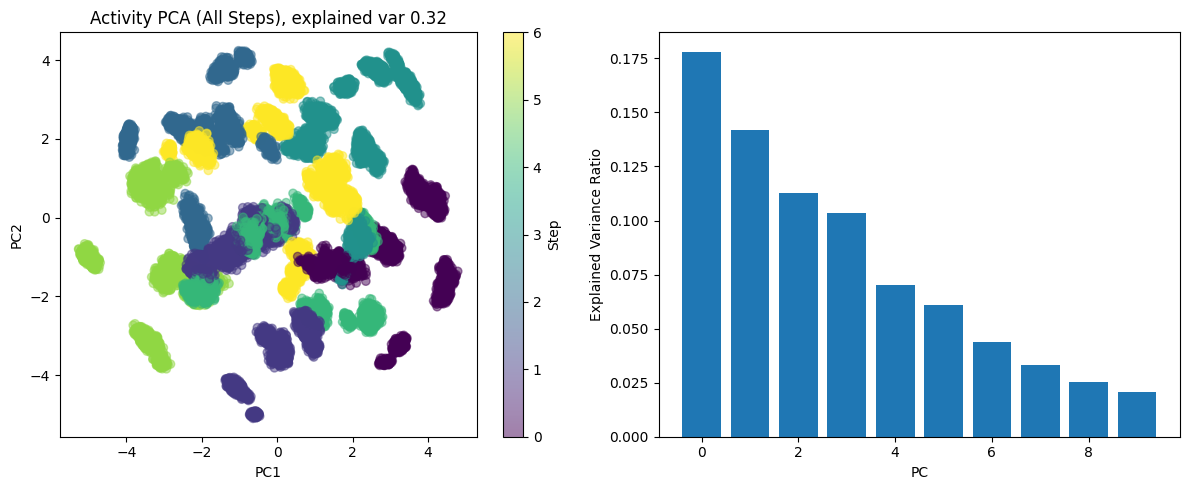

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Concatenate the data (your original code)
every_activities = np.concatenate(list(activities_by_step.values()), axis=0)
every_selected_activities = np.concatenate(list(selected_activities_by_step.values()), axis=0) 

# 2. Create an array of step labels that matches the rows of every_selected_activities
# We repeat the 'step' key for however many rows are in its corresponding array
steps_array = np.concatenate([
    np.full(activities.shape[0], step) 
    for step, activities in selected_activities_by_step.items()
])
latents_array = np.concatenate([
    latents_by_step[step][...,latent_idx]
    for step in selected_activities_by_step.keys()
])

# 3. Perform PCA
pca = PCA(n_components=10)
A_reduced = pca.fit_transform(every_selected_activities)

# 4. Plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Use the steps_array for the 'c' argument to color by step
scatter = ax[0].scatter(A_reduced[:, 0], A_reduced[:, 1], c=latents_array, alpha=0.5, cmap='viridis')

# Add a colorbar to interpret the steps
cbar = fig.colorbar(scatter, ax=ax[0])
cbar.set_label('Step')

# Updated title to reflect that this is all steps combined
ax[0].set_title(f"Activity PCA (All Steps), explained var {pca.explained_variance_ratio_[:2].sum():.2f}")
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")

ax[1].bar(range(len(pca.explained_variance_ratio_)), pca.explained_variance_ratio_)
ax[1].set_xlabel("PC")
ax[1].set_ylabel("Explained Variance Ratio")

plt.tight_layout()
plt.show()

/tmp/ipykernel_3492727/3454601328.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


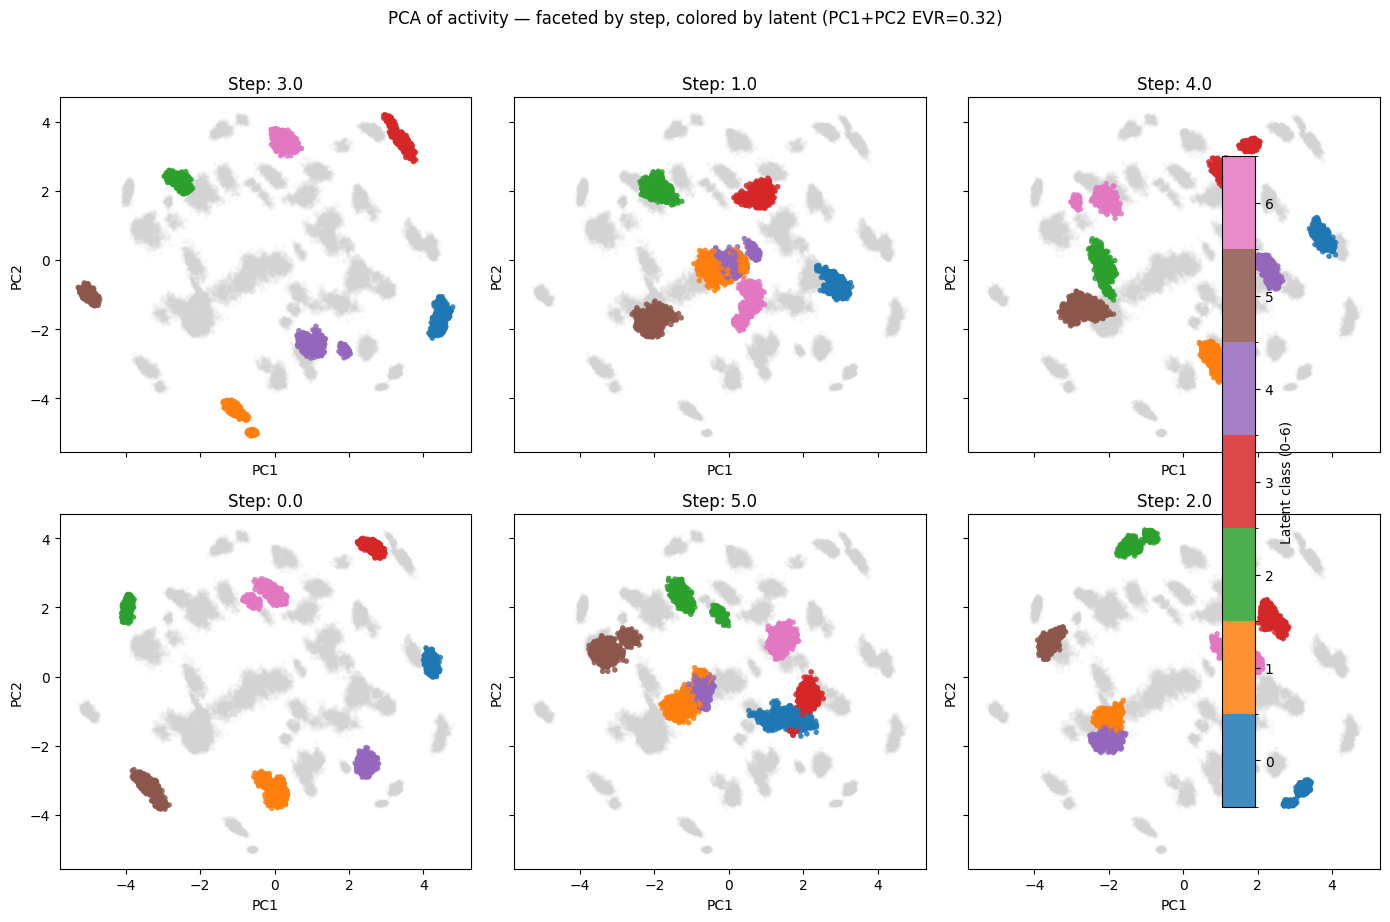

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap, BoundaryNorm

# ---- 1) Concatenate activities (same as you) ----
every_selected_activities = np.concatenate(list(selected_activities_by_step.values()), axis=0)

# ---- 2) Step labels aligned with rows ----
steps_array = np.concatenate([
    np.full(activities.shape[0], step)
    for step, activities in selected_activities_by_step.items()
])

# ---- 3) Latent labels (single index 0..6) aligned with rows ----
# (ensure 1D int array)
latents_array = np.concatenate([
    np.asarray(latents_by_step[step])[..., latent_idx].reshape(-1)
    for step in selected_activities_by_step.keys()
]).astype(int)

# ---- 4) PCA ----
pca = PCA(n_components=10)
A_reduced = pca.fit_transform(every_selected_activities)

# ---- 5) Facet by step, color by latent (categorical) ----
unique_steps = list(dict.fromkeys(steps_array))  # preserves order
n_steps = len(unique_steps)                      # should be 6
n_latents = 7

fig, axes = plt.subplots(2, 3, figsize=(14, 9), sharex=True, sharey=True)
axes = axes.ravel()

# discrete colormap for 7 classes
base = plt.get_cmap("tab10")
cmap = ListedColormap([base(i) for i in range(n_latents)])
bounds = np.arange(-0.5, n_latents + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

for i, step in enumerate(unique_steps):
    ax = axes[i]
    m = (steps_array == step)

    # optional: show all points faintly for global structure
    ax.scatter(A_reduced[:, 0], A_reduced[:, 1], c="lightgray", s=8, alpha=0.12, linewidths=0)

    sc = ax.scatter(
        A_reduced[m, 0], A_reduced[m, 1],
        c=latents_array[m],cmap=cmap,
         norm=norm,
        s=16, alpha=0.85, linewidths=0
    )

    ax.set_title(f"Step: {step}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

# If fewer than 6 steps, hide unused axes
for j in range(n_steps, 6):
    axes[j].axis("off")

# one shared colorbar for latent classes
cbar = fig.colorbar(sc, ax=axes[:6], fraction=0.03, pad=0.02, ticks=np.arange(n_latents))
cbar.set_label("Latent class (0–6)")

fig.suptitle(f"PCA of activity — faceted by step, colored by latent (PC1+PC2 EVR={pca.explained_variance_ratio_[:2].sum():.2f})",
             y=1.02)
plt.tight_layout()
plt.show()

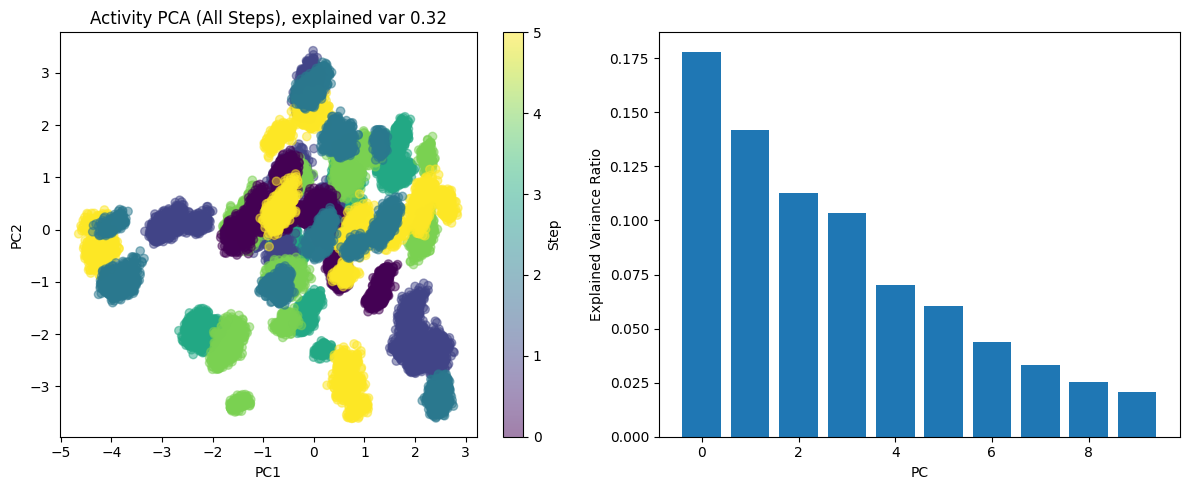

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Concatenate the data (your original code)
every_activities = np.concatenate(list(activities_by_step.values()), axis=0)
every_selected_activities = np.concatenate(list(selected_activities_by_step.values()), axis=0) 

# 2. Create an array of step labels that matches the rows of every_selected_activities
# We repeat the 'step' key for however many rows are in its corresponding array
steps_array = np.concatenate([
    np.full(activities.shape[0], step) 
    for step, activities in selected_activities_by_step.items()
])

# 3. Perform PCA
pca = PCA(n_components=10)
A_reduced = pca.fit_transform(every_selected_activities)

# 4. Plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Use the steps_array for the 'c' argument to color by step
scatter = ax[0].scatter(A_reduced[:, 4], A_reduced[:, 5], c=steps_array, alpha=0.5, cmap='viridis')

# Add a colorbar to interpret the steps
cbar = fig.colorbar(scatter, ax=ax[0])
cbar.set_label('Step')

# Updated title to reflect that this is all steps combined
ax[0].set_title(f"Activity PCA (All Steps), explained var {pca.explained_variance_ratio_[:2].sum():.2f}")
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")

ax[1].bar(range(len(pca.explained_variance_ratio_)), pca.explained_variance_ratio_)
ax[1].set_xlabel("PC")
ax[1].set_ylabel("Explained Variance Ratio")

plt.tight_layout()
plt.show()

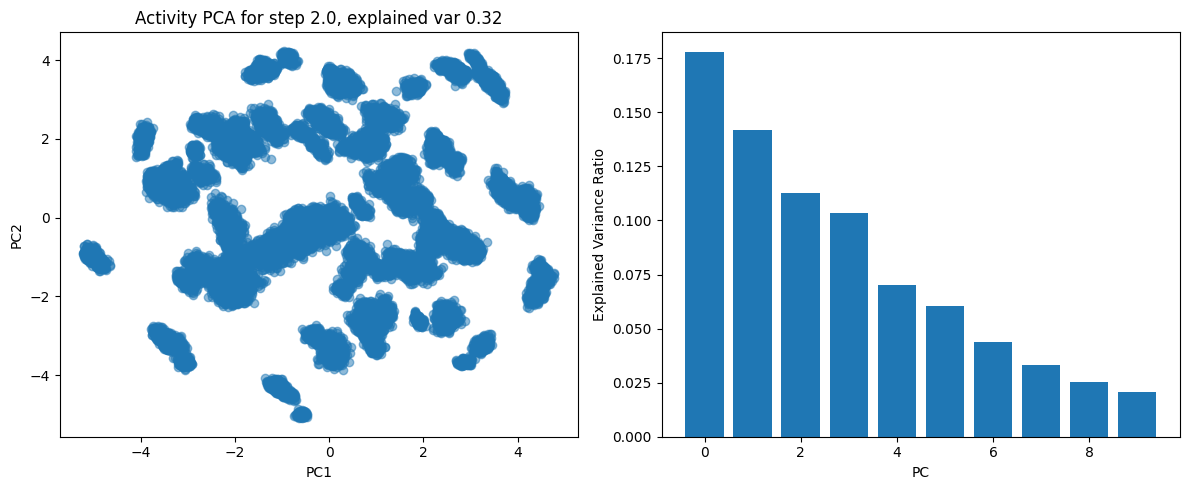

In [57]:
pca = PCA(n_components=10)
A_reduced = pca.fit_transform(every_selected_activities)
fig,ax = plt.subplots(1,2, figsize=(12,5))
ax[0].scatter(A_reduced[:,0], A_reduced[:,1], alpha=0.5)
ax[0].set_title(f"Activity PCA for step {step}, explained var {pca.explained_variance_ratio_[:2].sum():.2f}")
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")
ax[1].bar(range(len(pca.explained_variance_ratio_)), pca.explained_variance_ratio_)
ax[1].set_xlabel("PC")
ax[1].set_ylabel("Explained Variance Ratio")
plt.tight_layout()
plt.show()

Step value: 3.0, Activity shape: (5760, 121)


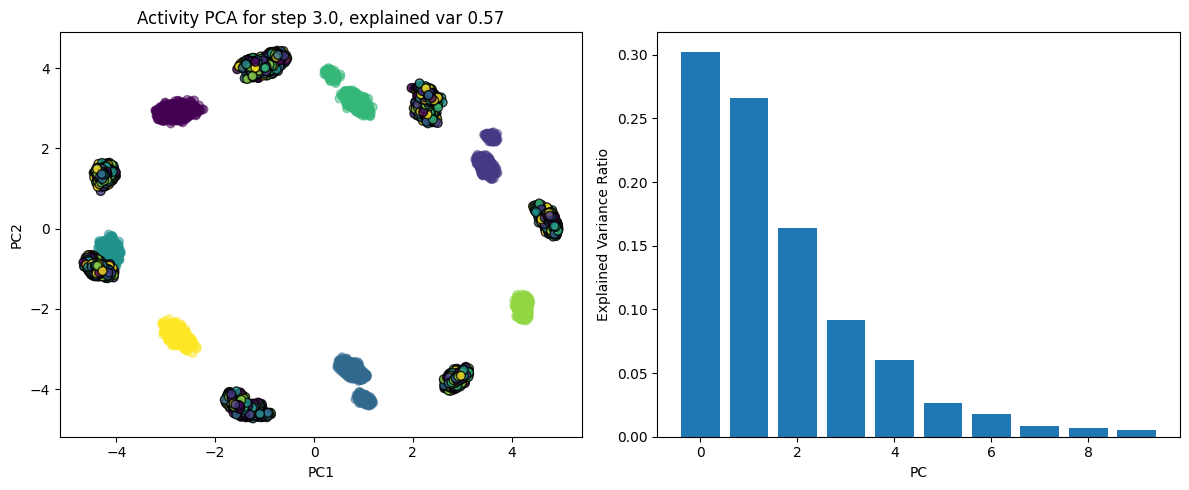

Step value: 1.0, Activity shape: (5760, 121)


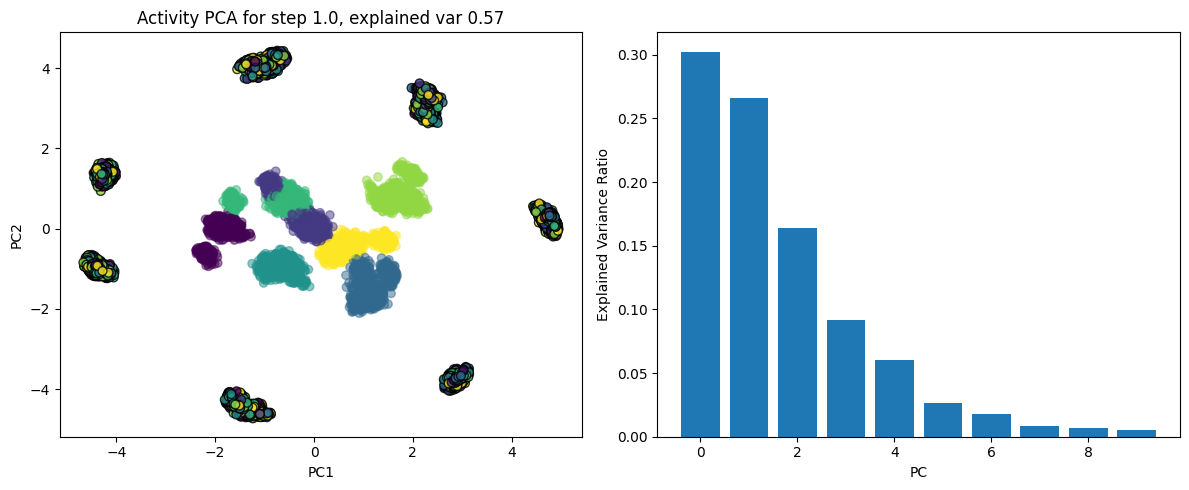

Step value: 4.0, Activity shape: (5760, 121)


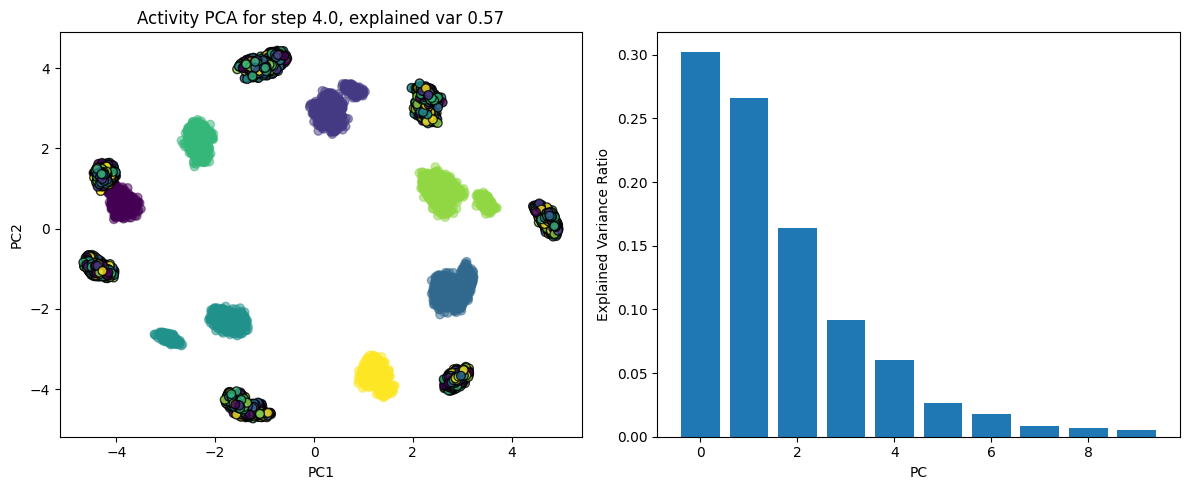

Step value: 0.0, Activity shape: (5760, 121)


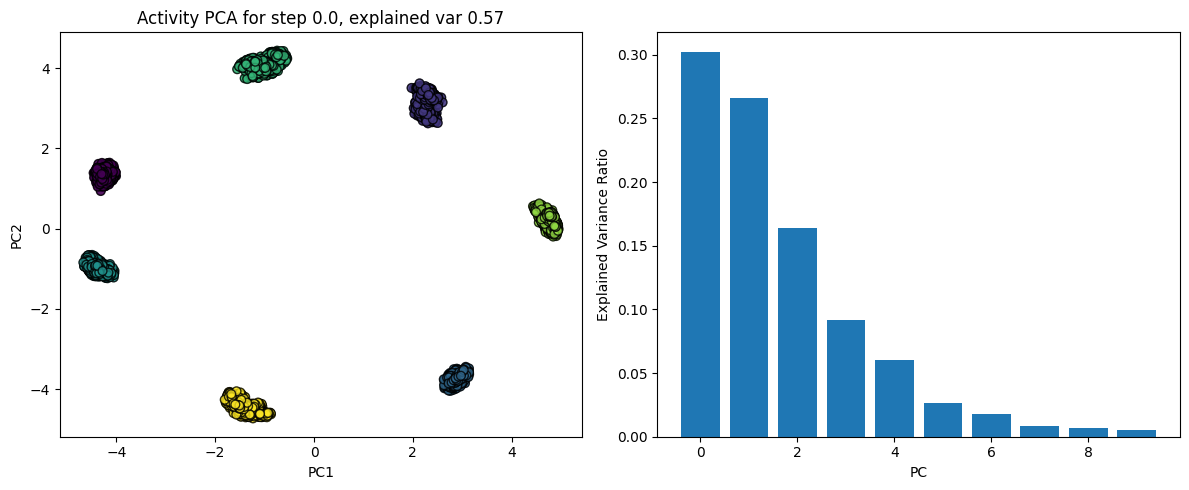

Step value: 5.0, Activity shape: (5760, 121)


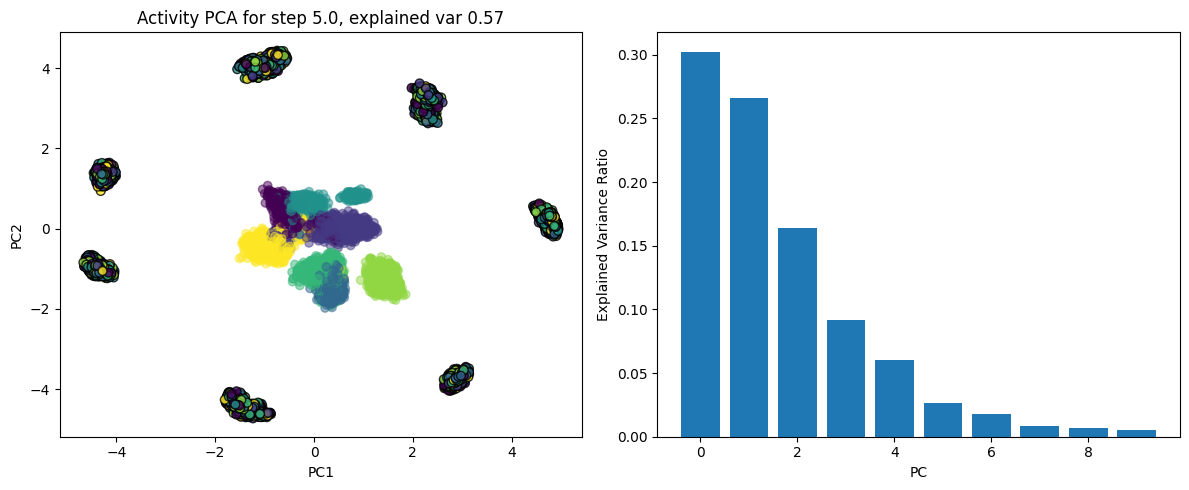

Step value: 2.0, Activity shape: (5760, 121)


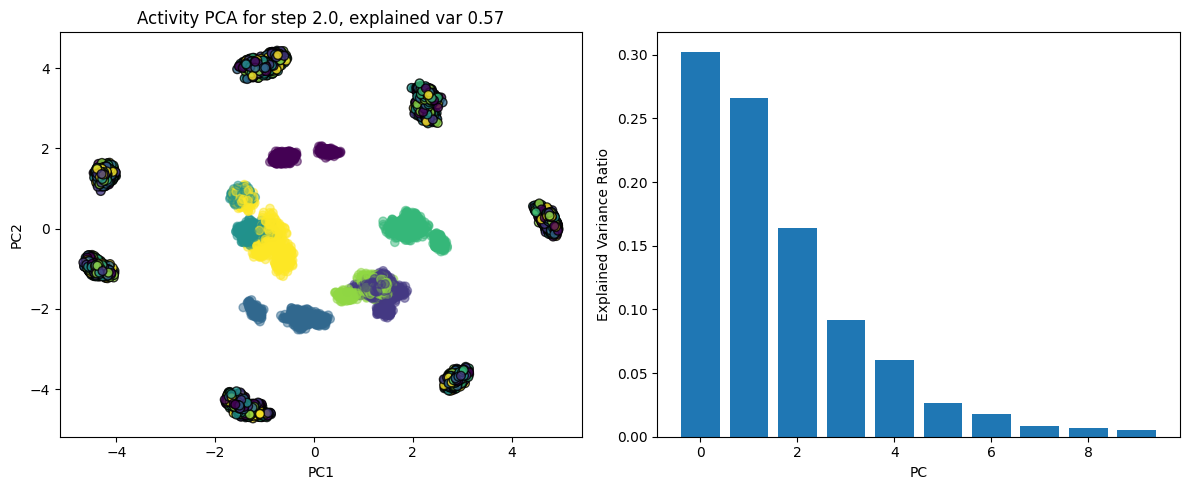

In [104]:
pca_of_step_zero = PCA(n_components=10)
pca_of_step_zero.fit(selected_activities_by_step[0])
zero_reduced = pca_of_step_zero.transform(selected_activities_by_step[0])

for step, A in selected_activities_by_step.items():
    print(f"Step value: {step}, Activity shape: {A.shape}")
    pca = PCA(n_components=10)
    A_reduced = pca_of_step_zero.transform(A)
    fig,ax = plt.subplots(1,2, figsize=(12,5))
    latents_for_step = latents_by_step[step][...,latent_idx]
    ax[0].scatter(A_reduced[:,0], A_reduced[:,1], c=latents_for_step, alpha=0.5, cmap='viridis')
    ax[0].scatter(zero_reduced[:,0], zero_reduced[:,1], c=latents_for_step, alpha=0.8, s=40, label='Step 3 (reference)', edgecolors='black')
    
    ax[0].set_title(f"Activity PCA for step {step}, explained var {pca_of_step_zero.explained_variance_ratio_[:2].sum():.2f}")
    ax[0].set_xlabel("PC1")
    ax[0].set_ylabel("PC2")
    ax[1].bar(range(len(pca_of_step_zero.explained_variance_ratio_)), pca_of_step_zero.explained_variance_ratio_)
    ax[1].set_xlabel("PC")
    ax[1].set_ylabel("Explained Variance Ratio")
    plt.tight_layout()
    plt.show()

Step value: 3.0, Activity shape: (5760, 121)


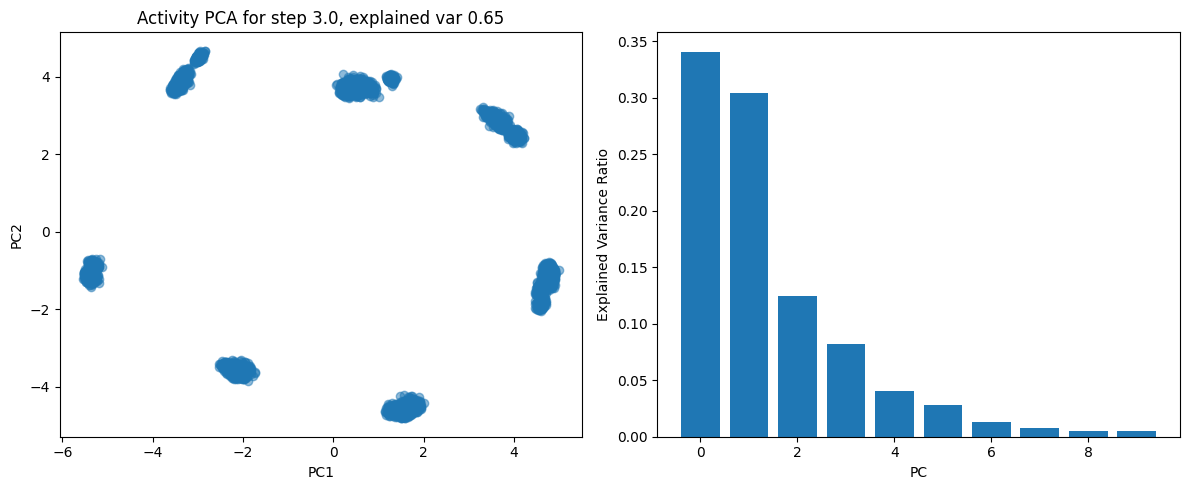

Step value: 1.0, Activity shape: (5760, 121)


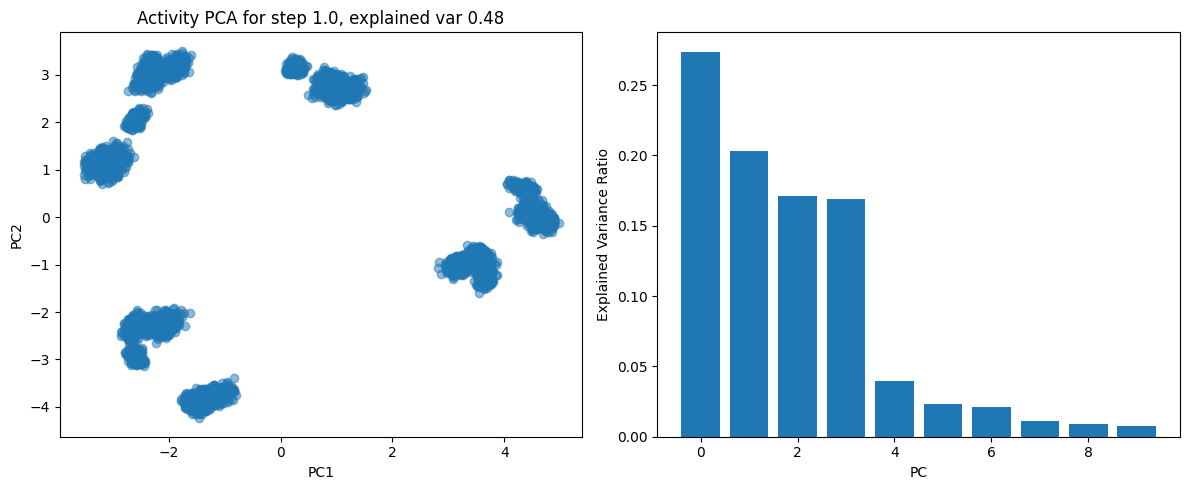

Step value: 4.0, Activity shape: (5760, 121)


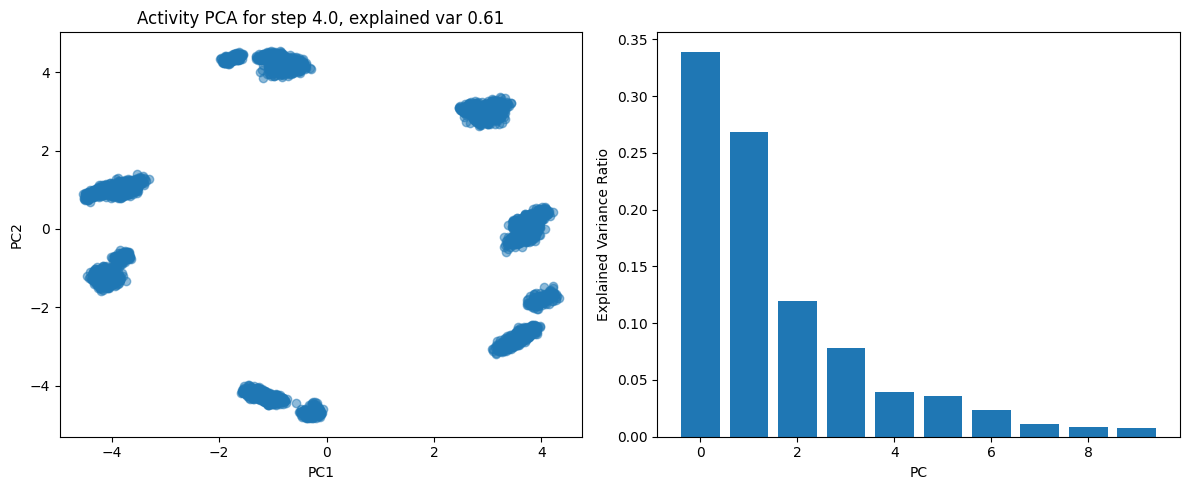

Step value: 0.0, Activity shape: (5760, 121)


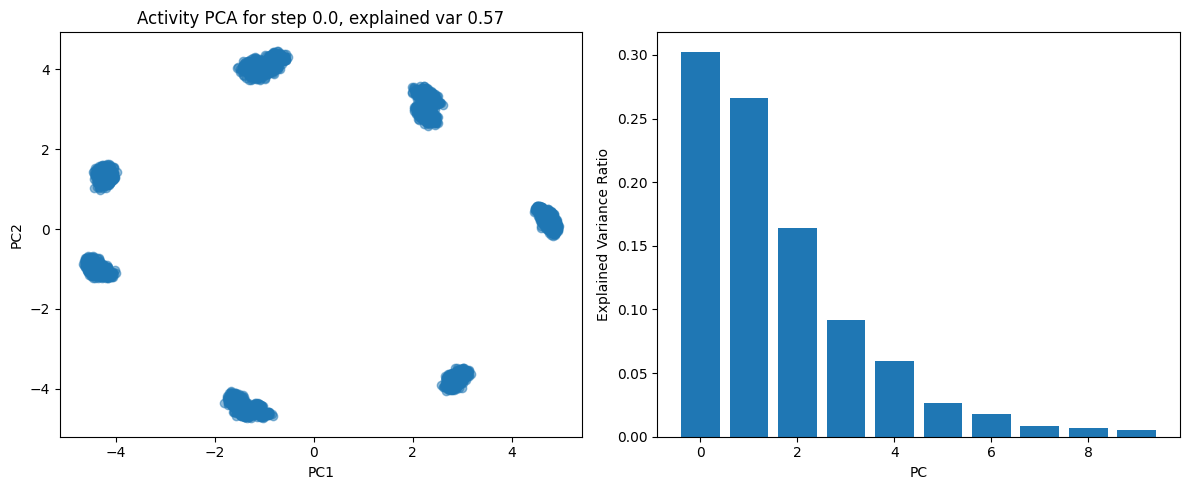

Step value: 5.0, Activity shape: (5760, 121)


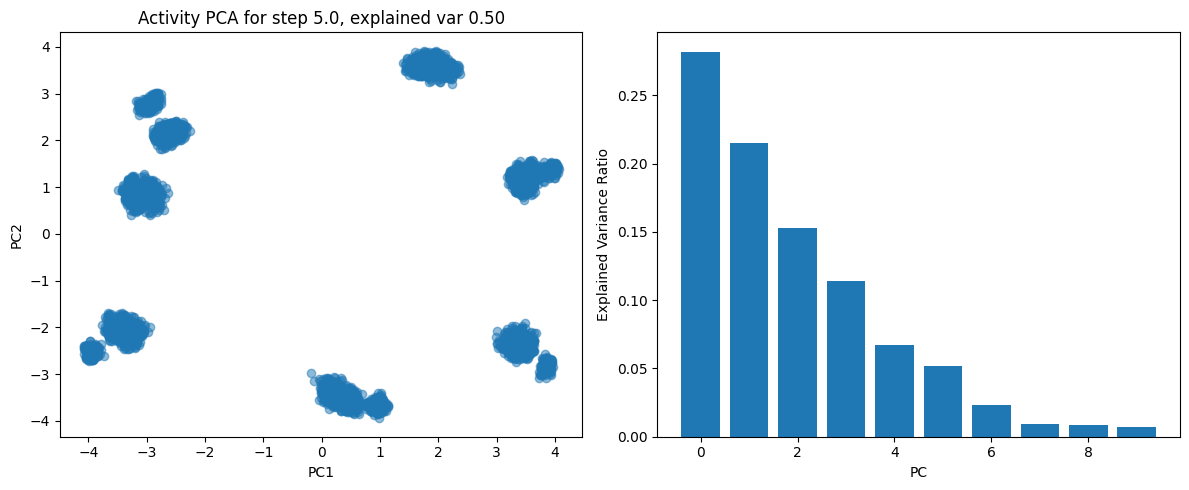

Step value: 2.0, Activity shape: (5760, 121)


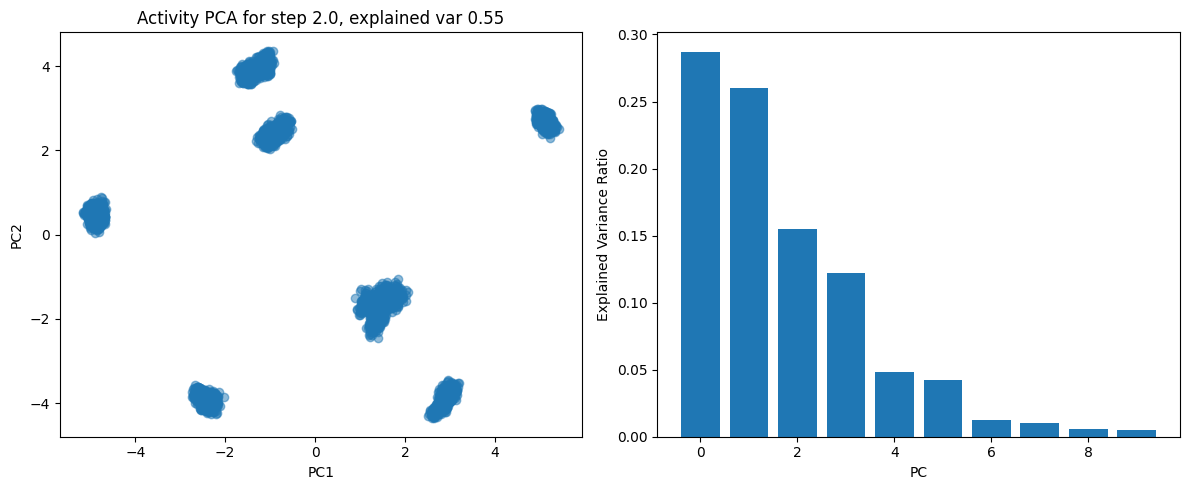

In [49]:
for step, A in selected_activities_by_step.items():
    print(f"Step value: {step}, Activity shape: {A.shape}")
    pca = PCA(n_components=10)
    A_reduced = pca.fit_transform(A)
    fig,ax = plt.subplots(1,2, figsize=(12,5))
    ax[0].scatter(A_reduced[:,0], A_reduced[:,1], alpha=0.5)
    ax[0].set_title(f"Activity PCA for step {step}, explained var {pca.explained_variance_ratio_[:2].sum():.2f}")
    ax[0].set_xlabel("PC1")
    ax[0].set_ylabel("PC2")
    ax[1].bar(range(len(pca.explained_variance_ratio_)), pca.explained_variance_ratio_)
    ax[1].set_xlabel("PC")
    ax[1].set_ylabel("Explained Variance Ratio")
    plt.tight_layout()
    plt.show()

In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

def pca_subspace(X, k=5, standardize=True, seed=0):
    if standardize:
        X = StandardScaler().fit_transform(X)
    pca = PCA(n_components=k, svd_solver="randomized", random_state=seed)
    pca.fit(X)
    # components_: [k, N] -> basis U: [N, k]
    U = pca.components_.T
    return U, pca.explained_variance_ratio_

def principal_angles(U, V):
    # U,V: [N,k] with orthonormal cols (PCA gives that)
    s = np.linalg.svd(U.T @ V, compute_uv=False)  # singular values in [0,1]
    s = np.clip(s, 0.0, 1.0)
    angles = np.arccos(s)  # radians, 0 = same subspace, pi/2 = orthogonal
    return angles, s

def subspace_overlap(U, V):
    _, s = principal_angles(U, V)
    return float(np.mean(s))  # 1 identical, 0 orthogonal (for same k)

In [51]:
def plot_subspace_similarity(activity_by_step, k=5, seed=0, title=""):
    steps = sorted(activity_by_step.keys())
    bases = {}
    for s in steps:
        U, evr = pca_subspace(activity_by_step[s], k=k, seed=seed)
        bases[s] = U

    S = np.zeros((len(steps), len(steps)))
    for i, si in enumerate(steps):
        for j, sj in enumerate(steps):
            S[i, j] = subspace_overlap(bases[si], bases[sj])

    plt.figure(figsize=(6, 5))
    plt.imshow(S, vmin=0, vmax=1, aspect="auto")
    plt.colorbar(label="mean cos(principal angle)")
    plt.xticks(range(len(steps)), steps, rotation=45, ha="right")
    plt.yticks(range(len(steps)), steps)
    plt.title(title or f"Subspace similarity (k={k})")
    plt.tight_layout()
    plt.show()

    return bases, S

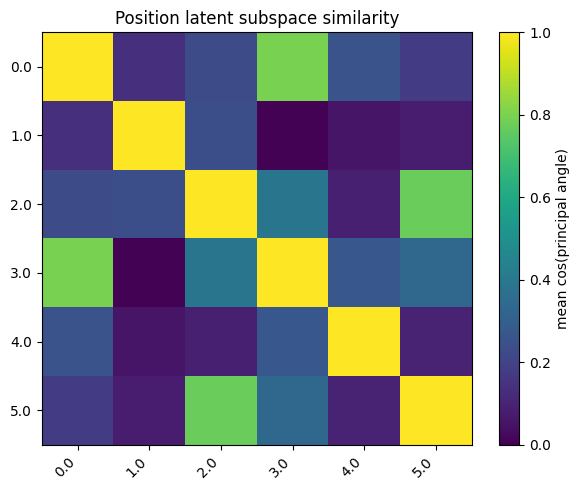

({0.0: array([[ 0.05979],
         [-0.16219],
         [-0.05041],
         [ 0.03682],
         [ 0.12918],
         [ 0.12934],
         [ 0.09752],
         [-0.1427 ],
         [-0.00952],
         [ 0.09714],
         [-0.05488],
         [ 0.00572],
         [ 0.16522],
         [-0.00155],
         [ 0.20144],
         [-0.00109],
         [-0.01576],
         [-0.18426],
         [ 0.07133],
         [ 0.01497],
         [-0.00383],
         [-0.06954],
         [ 0.17966],
         [-0.13124],
         [ 0.03091],
         [ 0.11532],
         [-0.00128],
         [ 0.08146],
         [ 0.03167],
         [-0.00774],
         [-0.17395],
         [-0.01419],
         [ 0.16122],
         [ 0.02979],
         [ 0.04226],
         [ 0.06638],
         [ 0.10403],
         [-0.1438 ],
         [ 0.07465],
         [-0.0565 ],
         [ 0.08856],
         [-0.05596],
         [-0.1561 ],
         [-0.07315],
         [-0.0866 ],
         [-0.02932],
         [-0.00133],
        

In [55]:
plot_subspace_similarity(selected_activities_by_step, k=1, seed=0, title="Position latent subspace similarity")